## 伪影

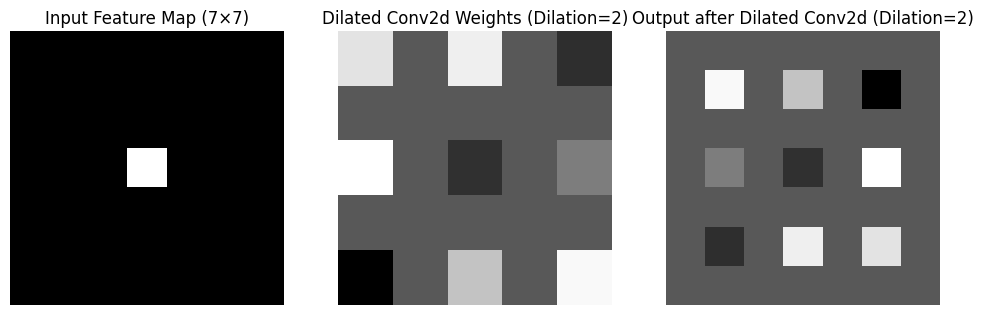

In [9]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from tool import create_equivalent_conv_kernel

# 设置随机种子
torch.manual_seed(42)
np.random.seed(42)

# 构建 1×1×10×10 的输入（batch=1, channel=1, H=10, W=10）
input_tensor = torch.zeros(1, 1, 7, 7)
input_tensor[0, 0, 3, 3] = 1.0


dilation2 = nn.Conv2d(in_channels=1, out_channels=1, kernel_size=3, dilation=2, padding=2, bias=False)
equal_kernel = create_equivalent_conv_kernel(dilation2.weight, dilation=2)
# print("Equivalent Conv2d Kernel:\n", equal_kernel)
output_tensor = dilation2(input_tensor)
# print("Output shape after Dilated Conv2d:", output_tensor.shape)


# 可视化输入
plt.figure(figsize=(12,4))
plt.subplot(1, 3, 1)
plt.imshow(input_tensor.squeeze().numpy(), cmap='gray')
plt.title("Input Feature Map (7×7)")
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(equal_kernel.squeeze(), cmap='gray')
plt.title("Dilated Conv2d Weights (Dilation=2)")
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(output_tensor.detach().squeeze().numpy(), cmap='gray')
plt.title("Output after Dilated Conv2d (Dilation=2)")
plt.axis('off')
plt.show()
